# 생성모델
## 1. 생성모델의 개념
### 1-1. 분류 모델 vs 생성 모델
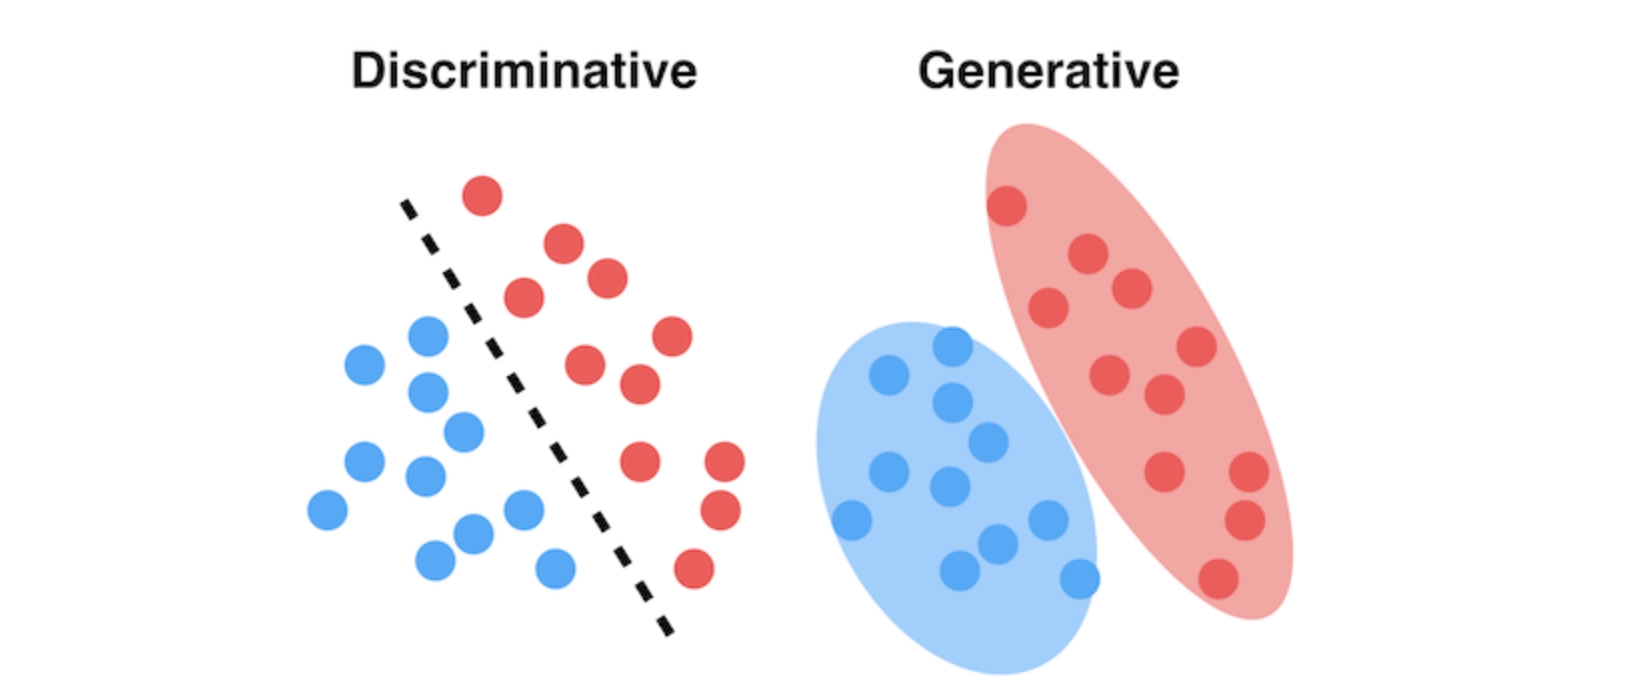  
1) 분류 모델
- 정답 레이블 있음
- X가 어떤 레이블(Y)에 속할지 결정
- 처음 본 데이터가 들어와도 기존 라벨 중 하나로 결론 내려야 함
2) 생성 모델
- 데이터 자체의 확률 분포를 학습하여 학습 데이터와 유사한 새로운 데이터를 만들어내는 모델
- 불합리하거나 이상한 입력에 대해서는 P(x)=0 이라고 판단하여 거부 가능
- 생성 : 데이터가 가진 특징의 분포를 배워서 그 분포 내에 존재할 법한 새로운 데이터를 샘플링하는 과정
3) 예시
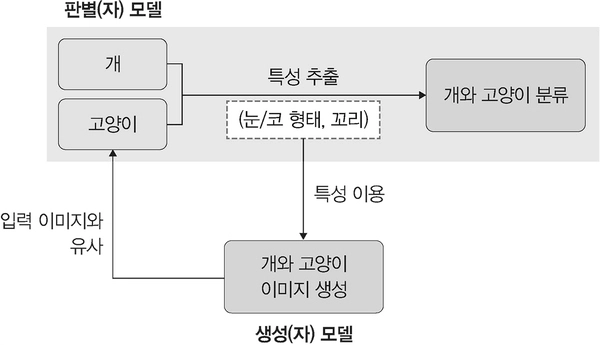

### 1-2. 생성 모델의 분류
1) 명시적 확률밀도 모델(Explicit density Models)
- 모델이 데이터의 확률 분포인 P(X)의 값을 직접적으로 수치화하여 출력할 수 있는 모델
- 정확히 계산 가능한 모델, 근사적 밀도 모델
2) 암시적 확률밀도 모델(Implicit density Models)
- 데이터의 확률 분포 P(X)가 무엇인지 수치로 알려주지는 않지만, 그 분포를 따르는 데이터를 생성(Sampling)할 수는 있는 모델
- 직접 샘플링, 간접/반복적 샘플링 (마르코브 체인)


# 2. AE, VAE
## 2.1 AE
1) Auto Encoder(AE)란?
- 오토인코더는 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망입니다.
- 차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등 데이터 복원이나 특성 학습에 많이 사용됩니다.
2) AE의 구조와 작동 : 넣고, 줄이고, 다시 키우기!
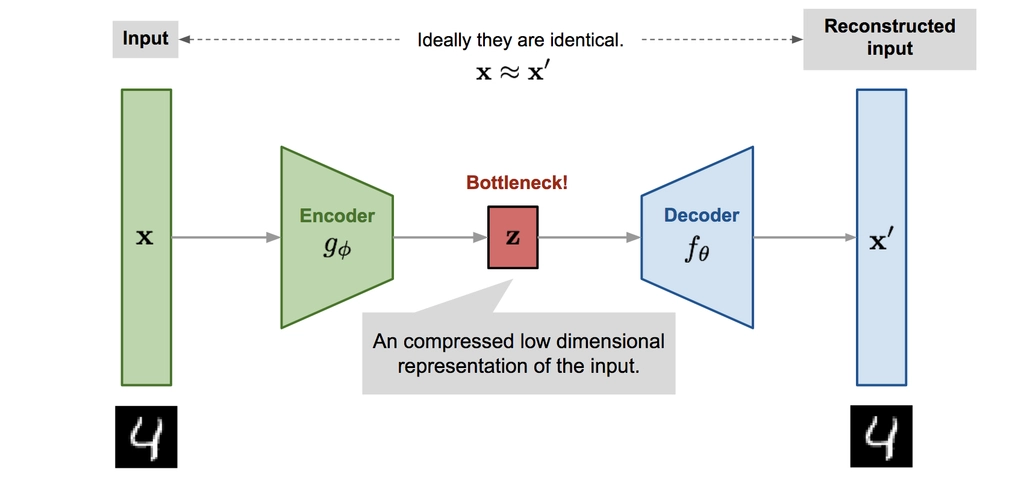  
- [Step 1] 압축 단계 (Encoder) - 고차원 입력 데이터(x)를 잠재표현(z)로 변환
- [Step 2] 병목 통과 (Bottleneck) - 잠재벡터 : 특징 정보 저장됨
- [Step 3] 복원 단계 (Decoder) - 잠재표현(z)를 풀어서 입력을 재복원하여 출력(x')
- 결국, AE는 인코더로 들어가는 입력 데이터 x와 디코더가 출력한 데이터 x'가 같아지도록 훈련하여 그 과정에서 데이터의 가장 중요한 특징(잠재 벡터)만 남기게 되는 모델입니다.

## 2.2 VAE
1) Variational Auto Encoder(VAE)란?
- AE의 한계 : 데이터를 잠재 공간의 특정 점으로 보냄 -> 학습할 때 쓰지 않은 빈 공간의 점을 찍으면 디코더는 무엇을 그려야 할지 몰라 엉뚱한 결과 출력
- VAE의 해결책 : 잠재 벡터를 점이 아닌 가우시안 분포(범위)로 학습 -> 잠재공간을 빈틈없이 촘촘하게 채워 어떤 점을 뽑아도 그럴듯한 이미지 생성
- 이미지 생성, 텍스트 생성, 신호 처리, 이미지 보간 등 새로운 데이터를 생성하는 작업에 많이 사용됩니다.

2) AE vs VAE
AE와 VAE의 가장 결정적인 차이 :  
"입력 데이터를 잠재 공간(Latent Space)에 어떤 형태로 배치하느냐"
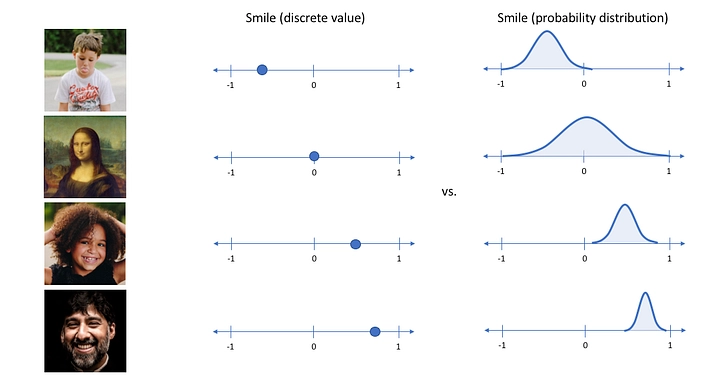  
- 좌 : AE, 우 : VAE

| **구분** | **Auto Encoder (AE)** | **Variational Auto Encoder (VAE)** |
| --- | --- | --- |
| **주인공** | **인코더 (압축이 중요)** - ***디코더**는 압축이 잘되었는지 검사하는 역할* | **디코더 (생성이 중요)** - ***인코더**는 디코더를 잘 학습시키기 위한 가이드* |
| **잠재 벡터 $z$의 형태** | **고정된 수치 (Point)** | **확률 분포 (Distribution)** |
| **잠재 공간의 특성** | 불연속적이고 비어있는 공간이 많음 | 연속적이며 표준 정규 분포를 따름 |
| **샘플링 결과** | 학습 데이터 외 구역에서는 복원이 불가능함 | 어느 지점에서든 의미 있는 생성이 가능함 |
| **주요 효과** | 데이터 압축 및 특징 추출 | **데이터 생성 및 보간 (Interpolation)** |

3) VAE의 구조와 작동 : 찾고, 뽑고, 다시 그리기!
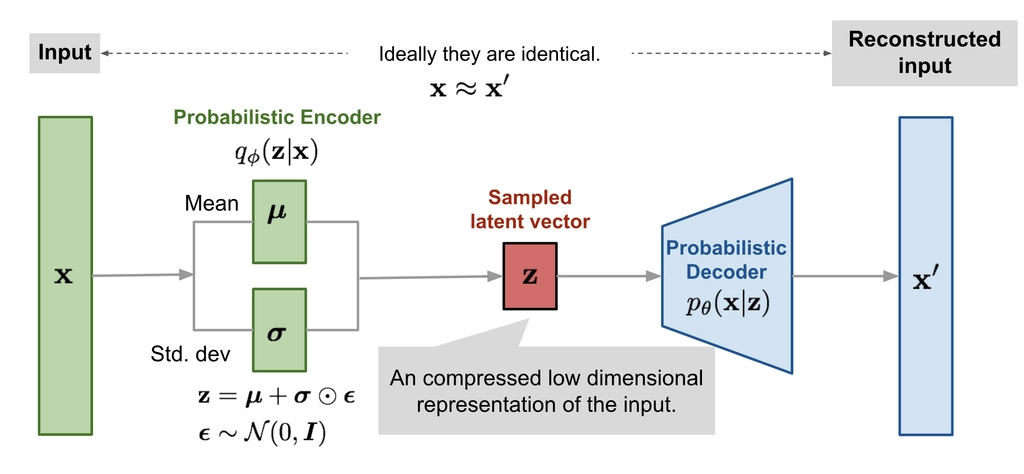  
- [Step 1] 분포 예측 단계 (Encoder) - 입력 데이터(𝑥)를 분석해 잠재 공간상의 평균(𝜇)과 표준편차(𝜎)를 계산합니다.
- [Step 2] 샘플링 및 재파라미터화 (Sampling & Reparameterization) - 예측한 분포에서 실제 디코더에 전달할 잠재 벡터(𝑧)를 하나 뽑는 단계입니다.
- [Step 3] 생성 단계 (Decoder) - 샘플링된 잠재 벡터(𝑧)를 단서로 사용하여 새로운 데이터를 생성합니다.



# 3. GAN
## 3.1 GAN의 개념
1) GAN(Generative Adversarial Network)이란?
- 생성적 적대 신경망은 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하면서, 훈련을 통하여 자신의 작업을 점점 더 정교하게 수행하는 신경망 모델입니다.
- 적대적 학습 : 생성자와 판별자는 서로를 이기기 위해 함께 성장합니다. 이 과정의 끝(최적점)에서 생성자는 진짜와 구분이 불가능한 완벽한 데이터를 만들어내고, 판별자는 진짜와 가짜를 찍어서 맞히는 수준(확률 0.5)에 도달하게 됩니다.

2) GAN의 목적
- 생성자(Generator)의 목적은 진짜 분포에 가까운 가짜분포를 생성하는 것
- 판별자(Discriminator)의 목적은 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지를 결정하는 것
- 따라서 GAN의 궁극적인 목적은 “실제 데이터의 분포”에 가까운 데이터를 생성하는 것이며, 판별자가 진짜/가짜를 한 쪽으로 판단하지 못하는 경계를 최적 솔루션으로 간주하게 됩니다.
- GAN은 이미지 생성, 영상 합성 등에 사용됨

## 3.2 GAN 구조
- GAN은 두 개의 신경망이 최소-최대 게임(MinMax Game)을 수행하는 구조입니다.
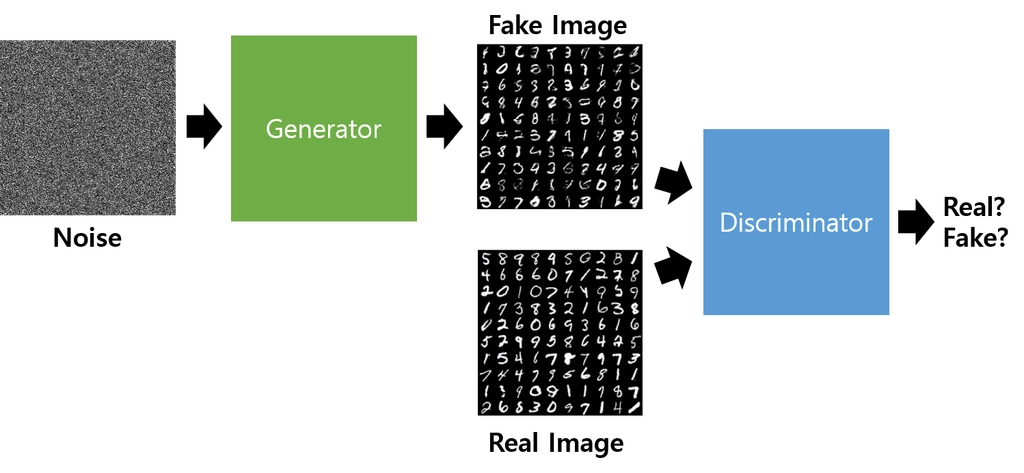  
- 생성자(Generator, G) - 무작위 노이즈(잠재변수 z) 입력, 가짜 데이터(G(z)) 출력
- 판별자(Discriminator, D) - 실제 데이터(x)와 생성자가 만든 가짜 데이터(G(z)) 입력, 입력 데이터가 진짜일 확률 출력(분류 모델)

## 3.3 GAN의 장단점
1) GAN의 장점
진짜 같은 가짜를 생성 / 압도적인 선명도 / 빠른 생성 속도 / 잠재 공간의 부드러움
2) GAN의 한계점
- 학습의 불안정성 (Instability) : 진동현상(에폭(Epoch)이 진행될수록 손실(Loss) 값이 떨어지지 않고 위아래로 크게 요동침), 끝없는 숨바꼭질 (이론적인 최적점에 도달하기보다는 G와 D가 서로를 이기기 위한 무한 루프에 빠짐)
- 훈련 초기 문제
- 모드 붕괴 (Mode Collapse) : 생성자가 판별자를 속이기 가장 쉬운 특정 패턴(예: 숫자 1) 하나만 주구장창 만드는 문제입니다. 다양성을 잃고 '한 놈만 패는' 현상.
- 지표의 부재 : 얼마나 잘 학습되고 있는지 보여주는 손실 곡선이 없음
- 역매핑 불가 : VAE는 입력(X)을 잠재 공간(Z)으로 보내는 인코더가 있어 특징 추출이 가능하지만, GAN은 오직 Z→X로 가는 일방통행로(생성자)만 존재

## 3.4 GAN 적용 사례
1) NVIDIA(2017) - 가짜 이미지 생성
2) University of Washington(2017) - 가짜 오바마 연설 영상
3) Facebook(2017) - Eye In-Painting

# 4. 확산 모델(Diffusion Model)
## 4.1 확산 모델(Diffusion Model)의 개념
1) 확산 모델이란?
- 입력 이미지에 노이즈를 조금씩 추가하여 완전한 노이즈로 만든 뒤, 
- 이를 다시 거꾸로 복원하는 과정을 학습하여 (노이즈 제거)
- 입력 이미지와 유사한 확률 분포를 가진 결과 이미지를 생성하는 모델입니다.
- 확산 모델의 흐름 : 원본 데이터→ 완전한 노이즈 → 원본 데이터
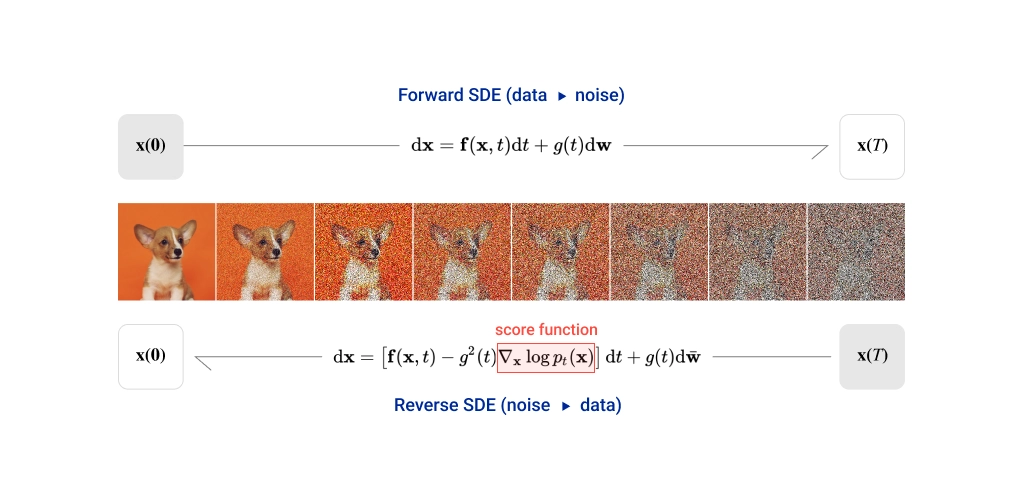
2) 확산 모델의 목적
- 목표: 순확산과 역확산 단계를 거쳐 생성된 '결과 이미지'의 확률 분포를 '원래 데이터'의 확률 분포와 최대한 유사하게 만드는 것입니다.

## 4.2 확산 모델의 구조 : 순확산과 역확산
1) 순확산 (Forward Diffusion Process)
- 순확산 과정은 데이터에 점진적으로 (정규분포를 가진)노이즈를 추가하는 과정입니다.
- 목표는 원래 데이터를 점차적으로 무작위 노이즈로 변형시키는 것
2) 역확산 (Reverse Diffusion Process) 
- 역확산(Reverse Diffusion) 과정은 노이즈 데이터에서 원본 데이터를 재구성하는 과정입니다.
- 목표는 순확산 과정에서 추가된 노이즈를 제거하여 원래의 데이터를 복원하는 것

## 4.3 확산 모델의 장단점
1) 장점
- 압도적인 샘플 품질, 학습의 안정성, 다양성 확보
2) 단점
- 느린 생성 속도 (가장 큰 한계), 높은 계산 비용, 구조적 제약

# 5. 마치며

1. 생성 모델 4개 한 눈에 비교하기 

| **구분** | **AE** | **VAE**  | **GAN**  | **Diffusion Model** |
| --- | --- | --- | --- | --- |
| **모델 분류** | 비지도 특징 학습 | **명시적 밀도 (근사)**, | **암시적 밀도 (직접)**, | **암시적 밀도 (간접/반복)** |
| **핵심 목표** | 데이터 압축 및 특징 추출 | 우도(*P*(*X*))의 하한(ELBO) 최대화 | 적대적 학습을 통한 데이터 분포 일치 | 점진적 노이즈 제거를 통한 복원 |
| **주요 구조** | Encoder-Decoder | 확률적 Encoder-Decoder | Generator-Discriminator | Forward-Reverse Process |
| **잠재 공간 (***Z***)** | 별도의 구조 강제 없음 | **알려진 확률 구조 (가우시안)** 강제 | 데이터 공간으로의 매핑 도구, | 데이터와 동일한 Shape의 노이즈 |
| **장점** | 비자명한 특징 추출 능력 우수 | 안정적인 학습, 잠재 공간 보간 가능 | **매우 선명하고 깨끗한 결과물** | **최고 수준의 품질**, 학습의 안정성 |
| **단점** | 새로운 데이터 생성에 한계 | 결과물이 흐릿(Blurry)해지는 경향 | 학습이 불안정하고 모드 붕괴 위험 | 생성 속도가 매우 느림 |

2. [참고] 실제 서비스 (Claude 피셜)

| **구분** | **대표 서비스** | **실제 기반 모델** | **주요 구조** | **설명** |
| --- | --- | --- | --- | --- |
| **💬 생성형 언어모델(LLM)** | ChatGPT, Claude, Gemini | GPT-5.2, Claude Opus 4.6, Gemini 3.1 Pro | Transformer (Decoder-only) | 자연어 생성 모델의 표준 구조. Self-Attention을 통해 문맥 기반 언어 생성. 2026년 현재 모델 간 성능 격차가 좁혀지며 용도별 특화 경쟁 중. |
| **🖼️ 이미지 생성모델** | ChatGPT Images, Midjourney v8, Stable Diffusion 3.5, Flux 2 | GPT Image 2 (DALL·E 브랜드 deprecated), Midjourney v8, SD 3.5, Flux 2 Pro | Diffusion 기반(대부분Latent Diffusion) | DALL·E 3는 2025년 말 deprecated되고 GPT Image 2로 대체됨. Flux 2(Black Forest Labs)가 오픈소스 진영에서 급부상하며Midjourney와 경쟁 중. |
| **🎵 음성·음악 생성 모델** | Suno v5, Udio, ElevenLabs Music | Suno v5, Udio v4, Eleven Music | Transformer + Diffusion 혼합형 | Suno v5가 품질 1위. ElevenLabs는 2025년 8월 음악 생성 시장에 진입하며 상업적으로 안전한 라이선스를 강점으로 내세움. Suno·Udio는 2025년 음반사와 저작권 소송 이후 합의 완료. |
| **🎥 영상생성 모델** | Sora 2, Runway Gen-4.5, Kling 3.0, Veo 3.1 | Diffusion + Transformer 3D | Video Diffusion (시공간 확산) | Sora 2(2025년 9월 출시)가 물리 법칙 기반 영상 생성으로 주목받음. 2026년 현재 네이티브 4K, 20초 이상 영상, 동기화 오디오 생성이 업계 표준으로 자리잡음. |